# From real curves
let us draw random affinity to generate activity curves and then derive the activity array at fixed concentration.

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.special import entr
import itertools

import sys
sys.path.append('../..')

from src.plot_helper import plot_grid_heatmap
from src.ligand_coding_model import *
from src.receptor_information import *
# --- 1. Define General Parameters ---
Nr = 3  # Number of receptors (e.g., r0, r1, r2)

# Binning parameters
# binning parameters influence the indexing of the response.
# this is why, we define them on top
Na,Nc = 3,10
# concentration bins
c_min = 0.01
c_max = 10.0
c_edges = np.logspace(np.log10(c_min), np.log10(c_max), Nc + 1)
c_centers = np.sqrt(c_edges[:-1] * c_edges[1:])
c_star = np.array([c_centers[c_centers.__len__()//2]])
# activity bins
a_edges = np.linspace(0, 1, Na + 1)
a_centers = 0.5*(a_edges[1:] + a_edges[:-1])
a_centers[0] = 0.
a_centers[-1] = 1.


In [36]:
print(c_star)
print(c_centers)

print(a_centers)

[0.44668359]
[0.01412538 0.02818383 0.05623413 0.11220185 0.22387211 0.44668359
 0.89125094 1.77827941 3.54813389 7.07945784]
[0.  0.5 1. ]


In [37]:
Nreplicas = 1 # number of time we generate random ligands to perform averages
L_values = np.array([96])
MI = np.zeros(L_values.shape[0],dtype=float)
for l_idx, L_curr in enumerate(L_values):
    mi_hetero = []
    for k in range(Nreplicas):
        Kcs_3hetero, Kos_3hetero, eps_3hetero = generate_Ks(L=L_curr, n_types=2, n_hetero_sample='all',Kc_Amp=50)
        A_3hetero_binned = generate_activity_matrix(eps_3hetero, Kcs_3hetero, Kos_3hetero, c_star, a_edges,indices_to_avg=[2,3,4,5])
        A_continuous = generate_continuous_A(eps_3hetero, Kcs_3hetero, Kos_3hetero, c_centers, a_edges,indices_to_avg=[2,3,4,5])
        mi_hetero.append(compute_mi(A_3hetero_binned))
    MI[l_idx] = np.mean(mi_hetero)


# 3. Concatenate them along the middle axis to get (L, 3, N)


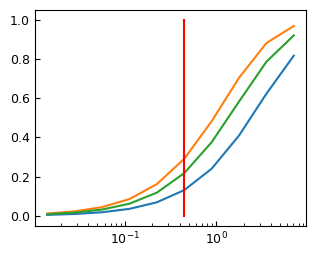

In [38]:
A_continuous.shape
for A in A_continuous[:1]:
    for a in A:
        plt.plot(c_centers,a)
plt.plot([c_star,c_star],[0,1],color='red')
plt.xscale('log')

In [39]:
A_3hetero_binned[2]

array([[0],
       [1],
       [1]])

[1.68073053]


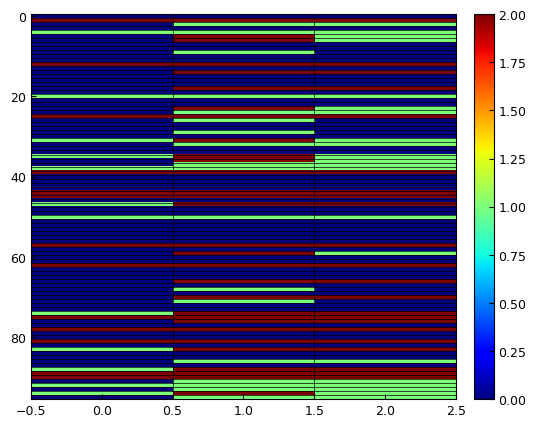

In [40]:
plot_grid_heatmap(A_3hetero_binned[:,:,0],figsize=(6,5))
print(MI)

In [6]:
A_continuous.shape

(96, 3, 10)

In [7]:
print(Kcs_3hetero[0])
print(A_3hetero[0])
A_3hetero = generate_activity_matrix(eps_3hetero, Kcs_3hetero, Kos_3hetero, c_centers, a_edges,indices_to_avg=[2,3,4,5])
print(A_3hetero[0])

[[17.88461665 17.88461665 17.88461665 17.88461665 17.88461665]
 [54.42161801 54.42161801 54.42161801 54.42161801 54.42161801]
 [17.88461665 17.88461665 17.88461665 17.88461665 54.42161801]
 [17.88461665 17.88461665 17.88461665 54.42161801 54.42161801]
 [17.88461665 17.88461665 54.42161801 54.42161801 54.42161801]
 [17.88461665 54.42161801 54.42161801 54.42161801 54.42161801]]


NameError: name 'A_3hetero' is not defined

In [ ]:
A_3hetero[0]

array([[0, 0, 0, 0, 0, 1, 2, 4, 6, 8],
       [0, 0, 0, 0, 1, 2, 4, 6, 8, 9],
       [0, 0, 0, 0, 1, 2, 3, 6, 8, 9]])